In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
mean_squared_error, mean_absolute_error, r2_score)
from xgboost import XGBClassifier, XGBRegressor

os.makedirs("models",  exist_ok=True)
os.makedirs("model_charts", exist_ok=True)

In [2]:
# Load data
df = pd.read_csv("cleaned_data.csv")
X = df.drop(columns=['Good_Investment','Future_Price_5Y'], errors='ignore')
y_clf = df['Good_Investment']
y_reg = df['Future_Price_5Y']

In [3]:
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
joblib.dump(imputer, "models/imputer.pkl")

['models/imputer.pkl']

In [4]:
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)
_,    _,  yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

Train: 200000 rows | Test: 50000 rows


In [5]:
# Classification
print("\n=== CLASSIFICATION ===")
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest"  : RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost"  : XGBClassifier(n_estimators=100, random_state=42,
                              eval_metric='logloss', verbosity=0),
}
clf_results = {}
for name, model in clf_models.items():
    model.fit(X_train, yc_train)
    yp = model.predict(X_test)
    yprob = model.predict_proba(X_test)[:,1]
    clf_results[name] = {
        "Accuracy" : round(accuracy_score(yc_test, yp), 4),
        "Precision": round(precision_score(yc_test, yp), 4),
        "Recall" : round(f1_score (yc_test, yp), 4),
        "F1-Score" : round(f1_score (yc_test, yp), 4),
        "ROC-AUC" : round(roc_auc_score (yc_test, yprob),4),
    }
    print(f" {name}: Acc={clf_results[name]['Accuracy']} F1={clf_results[name]['F1-Score']} AUC={clf_results[name]['ROC-AUC']}")

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['F1-Score'])
best_clf = clf_models[best_clf_name]
joblib.dump(best_clf, "models/classifier.pkl")
print(f"\n Best Classifier: {best_clf_name}")
    


=== CLASSIFICATION ===
 Logistic Regression: Acc=0.9758 F1=0.9697 AUC=0.9982
 Random Forest: Acc=0.9987 F1=0.9984 AUC=1.0
 XGBoost: Acc=0.9987 F1=0.9983 AUC=1.0

 Best Classifier: Random Forest


In [6]:
# Confusion Matrix chart
fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(
    confusion_matrix(yc_test, best_clf.predict(X_test)),
    display_labels=["Not Good","Good Investment"]
).plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {best_clf_name}", fontweight="bold")
plt.tight_layout(); plt.savefig("model_charts/clf_confusion_matrix.png"); plt.close()

In [7]:
# Feature Importance chart

if hasattr(best_clf, 'feature_importances_'):
    fig, ax = plt.subplots(figsize=(9,6))
    fi = pd.Series(best_clf.feature_importances_, index=X.columns)
    fi.sort_values(ascending=True).tail(15).plot(kind='barh', ax=ax, color='#4C72B0')
    ax.set_title(f"Feature Importance — {best_clf_name}", fontweight="bold")
    plt.tight_layout(); plt.savefig("model_charts/clf_feature_importance.png"); plt.close()

In [8]:
# Model comparison chart (Classification)
fig, ax = plt.subplots(figsize=(10,5))
metrics = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC']
x       = np.arange(len(metrics)); width = 0.22
colors  = ['#4C72B0','#55A868','#C44E52']
for i,(mname,color) in enumerate(zip(clf_results.keys(), colors)):
    vals = [clf_results[mname][m] for m in metrics]
    ax.bar(x + i*width, vals, width, label=mname, color=color, alpha=0.85, edgecolor='white')
    for j,v in enumerate(vals):
        ax.text(x[j]+i*width, v+0.01, f"{v:.2f}", ha='center', fontsize=7)
ax.set_xticks(x+width); ax.set_xticklabels(metrics); ax.set_ylim(0,1.15)
ax.set_title("Classification Model Comparison", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.savefig("model_charts/clf_model_comparison.png"); plt.close()
 
print("Charts saved: clf_confusion_matrix, clf_feature_importance, clf_model_comparison")


Charts saved: clf_confusion_matrix, clf_feature_importance, clf_model_comparison


In [9]:
# Regression
print("\n=== REGRESSION ===")
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest"    : RandomForestRegressor(n_estimators=50, random_state=42),  # 100→50
    "XGBoost"          : XGBRegressor(n_estimators=50, random_state=42, verbosity=0),  # 100→50
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, yr_train)
    yp = model.predict(X_test)
    reg_results[name] = {
        "RMSE" : round(float(np.sqrt(mean_squared_error(yr_test, yp))), 4),
        "MAE"  : round(float(mean_absolute_error(yr_test, yp)),         4),
        "R²"   : round(float(r2_score(yr_test, yp)),                    4),
        "CV-R²": round(float(cross_val_score(model, X, y_reg, cv=3, scoring='r2').mean()), 4),  # 5→3
    }
    print(f"  {name}: RMSE={reg_results[name]['RMSE']}  R²={reg_results[name]['R²']}  CV-R²={reg_results[name]['CV-R²']}")



=== REGRESSION ===
  Linear Regression: RMSE=210.0788  R²=-0.0001  CV-R²=0.9936
  Random Forest: RMSE=212.9651  R²=-0.0277  CV-R²=1.0
  XGBoost: RMSE=211.131  R²=-0.0101  CV-R²=1.0


In [12]:
best_reg_name = min(reg_results, key=lambda k: reg_results[k]['RMSE'])
best_reg      = reg_models[best_reg_name]
joblib.dump(best_reg,        "models/regressor.pkl")
joblib.dump(list(X.columns), "models/feature_names.pkl")
print(f"★ Best Regressor: {best_reg_name}")

★ Best Regressor: Linear Regression


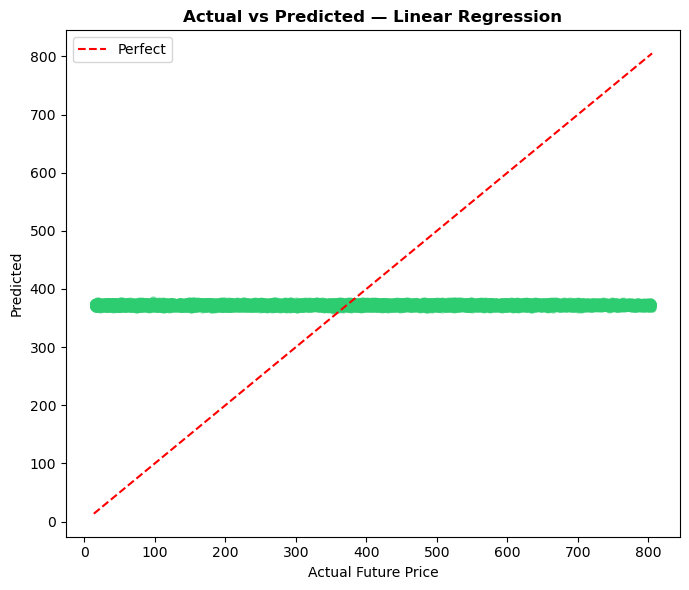

In [18]:
# Actual vs Predicted Chart
fig, ax = plt.subplots(figsize=(7,6))
yp_best = best_reg.predict(X_test)
ax.scatter(yr_test, yp_best, alpha=0.45, color='#2ecc71', s=25)
mn, mx = min(yr_test.min(), yp_best.min()), max(yr_test.max(), yp_best.max())
ax.plot([mn,mx],[mn,mx], 'r--', linewidth=1.5, label='Perfect')
ax.set_title(f"Actual vs Predicted — {best_reg_name}", fontweight="bold")
ax.set_xlabel("Actual Future Price")
ax.set_ylabel("Predicted")
ax.legend()
plt.tight_layout()
plt.savefig("model_charts/reg_actual_vs_predicted.png")
plt.show()

In [15]:
# Residual plot
fig, ax = plt.subplots(figsize=(8,5))
resid = yr_test.values - yp_best
ax.scatter(yp_best, resid, alpha=0.45, color='#9b59b6', s=25)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f"Residual Plot — {best_reg_name}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Residuals")
plt.tight_layout(); plt.savefig("model_charts/reg_residual_plot.png"); plt.close()
 
print("Charts saved: reg_actual_vs_predicted, reg_residual_plot")

Charts saved: reg_actual_vs_predicted, reg_residual_plot


In [16]:
print("\n=== CLASSIFICATION SUMMARY ===")
print(pd.DataFrame(clf_results).T.to_string())
print("\n=== REGRESSION SUMMARY ===")
print(pd.DataFrame(reg_results).T.to_string())
 
print("\n✅ Step 3 Done!")
print("   models/classifier.pkl    → best classifier")
print("   models/regressor.pkl     → best regressor")
print("   models/feature_names.pkl → feature list")
print("   models/imputer.pkl       → imputer")
 


=== CLASSIFICATION SUMMARY ===
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.9758     0.9684  0.9697    0.9697   0.9982
Random Forest          0.9987     0.9984  0.9984    0.9984   1.0000
XGBoost                0.9987     0.9981  0.9983    0.9983   1.0000

=== REGRESSION SUMMARY ===
                       RMSE       MAE      R²   CV-R²
Linear Regression  210.0788  180.8504 -0.0001  0.9936
Random Forest      212.9651  182.5416 -0.0277  1.0000
XGBoost            211.1310  181.4820 -0.0101  1.0000

✅ Step 3 Done!
   models/classifier.pkl    → best classifier
   models/regressor.pkl     → best regressor
   models/feature_names.pkl → feature list
   models/imputer.pkl       → imputer
